In [2]:
!pip install tensorflow numpy scikit-learn matplotlib opencv-python pillow

  Using cached tensorflow-2.21.0-cp313-cp313-win_amd64.whl.metadata (4.5 kB)
  Using cached opencv_python-4.13.0.92-cp37-abi3-win_amd64.whl.metadata (20 kB)
  Using cached absl_py-2.4.0-py3-none-any.whl.metadata (3.3 kB)
  Using cached astunparse-1.6.3-py2.py3-none-any.whl.metadata (4.4 kB)
  Using cached flatbuffers-25.12.19-py2.py3-none-any.whl.metadata (1.0 kB)
  Using cached gast-0.7.0-py3-none-any.whl.metadata (1.5 kB)
  Using cached google_pasta-0.2.0-py3-none-any.whl.metadata (814 bytes)
  Using cached libclang-18.1.1-py2.py3-none-win_amd64.whl.metadata (5.3 kB)
  Using cached opt_einsum-3.4.0-py3-none-any.whl.metadata (6.3 kB)
  Using cached protobuf-7.34.0-cp310-abi3-win_amd64.whl.metadata (595 bytes)
  Using cached termcolor-3.3.0-py3-none-any.whl.metadata (6.5 kB)
  Using cached grpcio-1.78.0-cp313-cp313-win_amd64.whl.metadata (3.9 kB)
  Using cached keras-3.13.2-py3-none-any.whl.metadata (6.3 kB)
  Using cached h5py-3.14.0-cp313-cp313-win_amd64.whl.metadata (2.7 kB)
  Using

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
streamlit 1.51.0 requires protobuf<7,>=3.20, but you have protobuf 7.34.0 which is incompatible.


In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.applications.vgg16 import VGG16
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.vgg16 import preprocess_input
from tensorflow.keras.models import Model

In [3]:
base_model = VGG16(weights='imagenet')

model = Model(inputs=base_model.input,
              outputs=base_model.get_layer('fc1').output)

print("Model Loaded")

553467096/553467096 ━━━━━━━━━━━━━━━━━━━━ 121s 0us/step
Model Loaded


In [5]:
def extract_features(img_path, model):

    img = image.load_img(img_path, target_size=(224,224))
    img = image.img_to_array(img)
    img = np.expand_dims(img, axis=0)

    img = preprocess_input(img)

    features = model.predict(img)

    return features.flatten()

In [6]:
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.vgg16 import preprocess_input
import numpy as np

def extract_features(img_path, model):
    
    img = image.load_img(img_path, target_size=(224,224))
    img = image.img_to_array(img)
    
    img = np.expand_dims(img, axis=0)
    img = preprocess_input(img)
    
    features = model.predict(img)
    
    return features.flatten()

In [9]:
import os

dataset_path = r"C:\CBIR_PROJECT\dataset"

image_paths = []

for root, dirs, files in os.walk(dataset_path):
    
    for file in files:
        
        if file.lower().endswith((".jpg",".png",".jpeg")):
            
            full_path = os.path.join(root,file)
            image_paths.append(full_path)

print("Total images:", len(image_paths))

Total images: 1000


In [10]:
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.vgg16 import preprocess_input
import numpy as np

def extract_features(img_path, model):
    
    img = image.load_img(img_path, target_size=(224,224))
    img = image.img_to_array(img)
    
    img = np.expand_dims(img, axis=0)
    img = preprocess_input(img)
    
    features = model.predict(img)
    
    return features.flatten()

In [11]:
img_path = image_paths[0]

feat = extract_features(img_path, model)

print("Feature vector size:", feat.shape)

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
Feature vector size: (4096,)


In [12]:
features = []
paths = []

for img_path in image_paths:
    
    feat = extract_features(img_path, model)
    
    features.append(feat)
    paths.append(img_path)

features = np.array(features)

print("Feature matrix shape:", features.shape)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 956ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 856ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 889ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 956ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 808ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step   
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 797ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 934ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step   
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step   
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step   
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/

In [14]:
import pickle

pickle.dump(features, open("features.pkl","wb"))
pickle.dump(paths, open("image_paths.pkl","wb"))

print("Features saved successfully")

Features saved successfully


In [15]:
import pickle

features = pickle.load(open("features.pkl","rb"))
image_paths = pickle.load(open("image_paths.pkl","rb"))

print(features.shape)
print(len(image_paths))

(1000, 4096)
1000


In [16]:
import pickle
import numpy as np

features = pickle.load(open("features.pkl","rb"))
image_paths = pickle.load(open("image_paths.pkl","rb"))

print("Features shape:", features.shape)
print("Total images:", len(image_paths))

Features shape: (1000, 4096)
Total images: 1000


In [17]:
from sklearn.metrics.pairwise import cosine_similarity

def search(query_image, model, features, image_paths, top_k=5):

    query_feature = extract_features(query_image, model)

    similarities = cosine_similarity([query_feature], features)

    indices = np.argsort(similarities[0])[::-1][:top_k]

    results = [image_paths[i] for i in indices]

    return results

In [18]:
query_image = image_paths[10]

results = search(query_image, model, features, image_paths, top_k=5)

print("Query Image:", query_image)

for r in results:
    print(r)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 952ms/step
Query Image: C:\CBIR_PROJECT\dataset\aeroplane\2008_003275.jpg
C:\CBIR_PROJECT\dataset\aeroplane\2008_003275.jpg
C:\CBIR_PROJECT\dataset\aeroplane\2008_008247.jpg
C:\CBIR_PROJECT\dataset\boat\2008_006730.jpg
C:\CBIR_PROJECT\dataset\car\2008_007346.jpg
C:\CBIR_PROJECT\dataset\boat\2008_006488.jpg


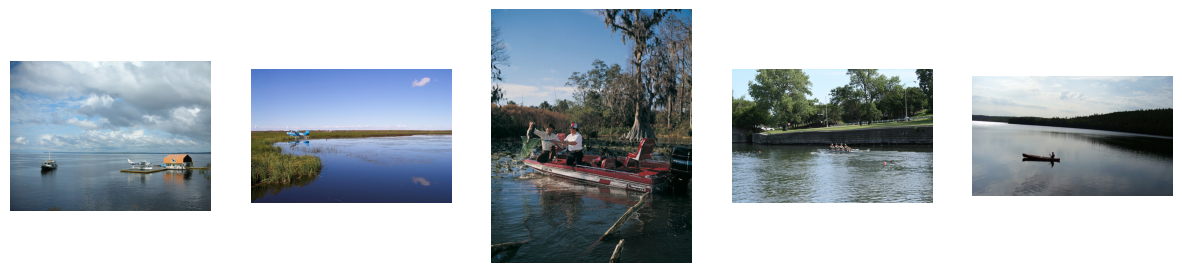

In [19]:
import matplotlib.pyplot as plt
import cv2

plt.figure(figsize=(15,5))

for i, img_path in enumerate(results):

    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.subplot(1,5,i+1)
    plt.imshow(img)
    plt.axis("off")

plt.show()

In [20]:
!pip install annoy

  Using cached annoy-1.17.3-cp313-cp313-win_amd64.whl


In [21]:
from annoy import AnnoyIndex

In [22]:
f = 4096
ann_index = AnnoyIndex(f, 'angular')

for i, vector in enumerate(features):
    ann_index.add_item(i, vector)

ann_index.build(10)   # number of trees

ann_index.save("image_index.ann")

print("Annoy index created")

Annoy index created


In [23]:
def search_annoy(query_image, model, ann_index, image_paths, top_k=5):
    
    query_vector = extract_features(query_image, model)
    
    indices = ann_index.get_nns_by_vector(query_vector, top_k)
    
    results = [image_paths[i] for i in indices]
    
    return results

In [24]:
query_image = image_paths[50]

results = search_annoy(query_image, model, ann_index, image_paths, top_k=5)

print("Query Image:", query_image)

for r in results:
    print(r)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
Query Image: C:\CBIR_PROJECT\dataset\bicycle\2008_000090.jpg
C:\CBIR_PROJECT\dataset\bicycle\2008_000090.jpg
C:\CBIR_PROJECT\dataset\bottle\2008_005752.jpg
C:\CBIR_PROJECT\dataset\dining_table\2008_006969.jpg
C:\CBIR_PROJECT\dataset\motorbike\2008_000393.jpg
C:\CBIR_PROJECT\dataset\dining_table\2008_008266.jpg


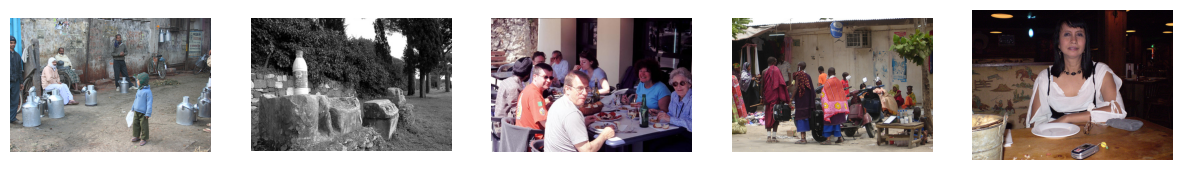

In [25]:
import matplotlib.pyplot as plt
import cv2

plt.figure(figsize=(15,5))

for i, img_path in enumerate(results):

    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.subplot(1,5,i+1)
    plt.imshow(img)
    plt.axis("off")

plt.show()

In [26]:
from sklearn.preprocessing import normalize

def extract_features(img_path, model):

    img = image.load_img(img_path, target_size=(224,224))
    img = image.img_to_array(img)

    img = np.expand_dims(img, axis=0)
    img = preprocess_input(img)

    features = model.predict(img)

    features = features.flatten()

    # normalize
    features = features / np.linalg.norm(features)

    return features

In [27]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Model

base_model = VGG16(weights="imagenet", include_top=False)

model = Model(
    inputs=base_model.input,
    outputs=base_model.layers[-1].output
)

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 17s 0us/step


In [28]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Model

base_model = VGG16(weights="imagenet", include_top=False)

model = Model(
    inputs=base_model.input,
    outputs=base_model.layers[-1].output
)

In [29]:
features = features.flatten()

In [31]:
query_image = r"C:\CBIR_PROJECT\dataset\bicycle\2008_000090.jpg"

In [33]:
features = []
paths = []

for img_path in image_paths:

    feat = extract_features(img_path, model)

    features.append(feat)
    paths.append(img_path)

features = np.array(features)

print(features.shape)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 830ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 867ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 891ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 935ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 837ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 793ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 831ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 803ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 817ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 922ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 987ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step   
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1000ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step   
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 899ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 810ms/step
1/1 ━━━━━━━━━━━

In [34]:
import pickle

pickle.dump(features, open("features.pkl","wb"))
pickle.dump(paths, open("image_paths.pkl","wb"))

In [36]:
from annoy import AnnoyIndex

f = 25088
ann_index = AnnoyIndex(f, 'angular')

for i, vector in enumerate(features):
    ann_index.add_item(i, vector)

ann_index.build(10)

ann_index.save(r"C:\CBIR_PROJECT\image_index.ann")

print("Annoy index saved successfully")

Annoy index saved successfully


In [37]:
results = search_annoy(query_image, model, ann_index, image_paths, top_k=10)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 973ms/step


In [38]:
def search_annoy(query_image, model, ann_index, image_paths, top_k=10):

    query_vector = extract_features(query_image, model)

    indices = ann_index.get_nns_by_vector(query_vector, top_k)

    results = [image_paths[i] for i in indices]

    return results

In [48]:
query_image = r"C:\CBIR_PROJECT\dataset\car\2008_001632.jpg"

In [49]:
results = search_annoy(query_image, model, ann_index, image_paths, top_k=10)

print("Query:", query_image)

for r in results:
    print(r)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 953ms/step
Query: C:\CBIR_PROJECT\dataset\car\2008_001632.jpg
C:\CBIR_PROJECT\dataset\car\2008_001632.jpg
C:\CBIR_PROJECT\dataset\car\2008_001274.jpg
C:\CBIR_PROJECT\dataset\car\2008_004080.jpg
C:\CBIR_PROJECT\dataset\car\2008_006762.jpg
C:\CBIR_PROJECT\dataset\boat\2008_005593.jpg
C:\CBIR_PROJECT\dataset\car\2008_008338.jpg
C:\CBIR_PROJECT\dataset\car\2008_006336.jpg
C:\CBIR_PROJECT\dataset\car\2008_007488.jpg
C:\CBIR_PROJECT\dataset\motorbike\2008_003892.jpg
C:\CBIR_PROJECT\dataset\car\2008_005960.jpg


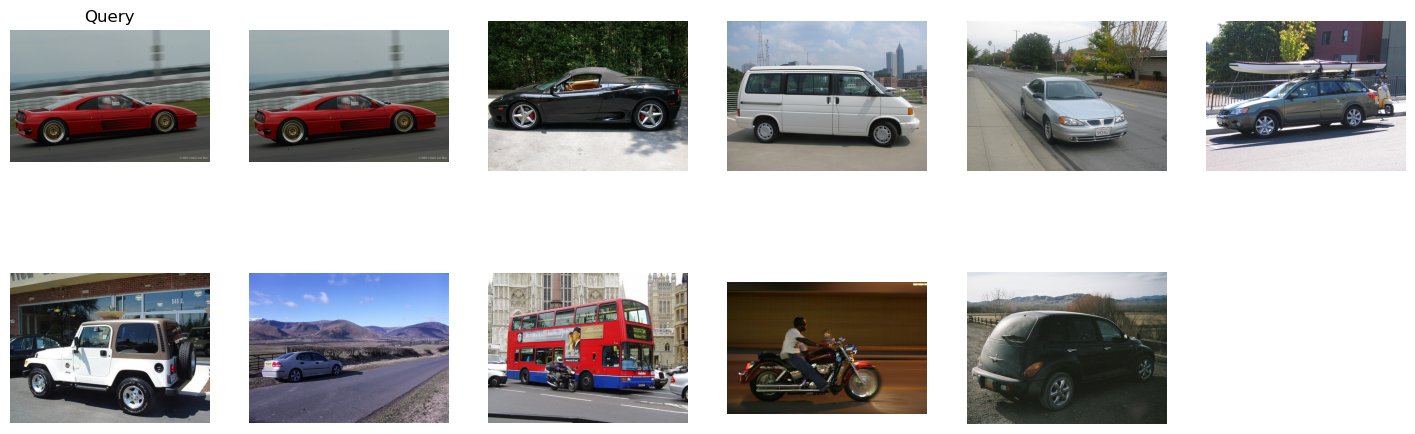

In [50]:
import matplotlib.pyplot as plt
import cv2

plt.figure(figsize=(18,6))

# show query image
img = cv2.imread(query_image)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.subplot(2,6,1)
plt.imshow(img)
plt.title("Query")
plt.axis("off")

# show retrieved images
for i, img_path in enumerate(results):

    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.subplot(2,6,i+2)
    plt.imshow(img)
    plt.axis("off")

plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step   
Query: C:\CBIR_PROJECT\dataset\aeroplane\2008_003369.jpg
C:\CBIR_PROJECT\dataset\aeroplane\2008_003369.jpg
C:\CBIR_PROJECT\dataset\aeroplane\2008_006621.jpg
C:\CBIR_PROJECT\dataset\aeroplane\2008_006619.jpg
C:\CBIR_PROJECT\dataset\aeroplane\2008_006623.jpg
C:\CBIR_PROJECT\dataset\aeroplane\2008_008044.jpg
C:\CBIR_PROJECT\dataset\aeroplane\2008_003703.jpg
C:\CBIR_PROJECT\dataset\aeroplane\2008_008373.jpg
C:\CBIR_PROJECT\dataset\aeroplane\2008_004532.jpg
C:\CBIR_PROJECT\dataset\aeroplane\2008_007504.jpg
C:\CBIR_PROJECT\dataset\aeroplane\2008_002358.jpg


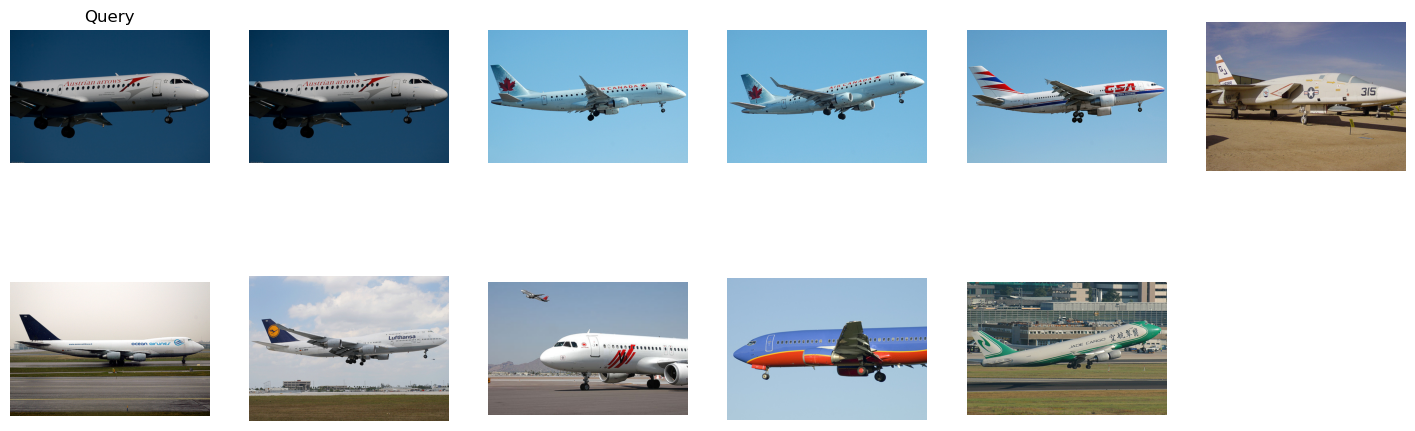

In [57]:
query_image = r"C:\CBIR_PROJECT\dataset\aeroplane\2008_003369.jpg"
results = search_annoy(query_image, model, ann_index, image_paths, top_k=10)

print("Query:", query_image)

for r in results:
    print(r)
    
import matplotlib.pyplot as plt
import cv2

plt.figure(figsize=(18,6))

# show query image
img = cv2.imread(query_image)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.subplot(2,6,1)
plt.imshow(img)
plt.title("Query")
plt.axis("off")

# show retrieved images
for i, img_path in enumerate(results):

    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.subplot(2,6,i+2)
    plt.imshow(img)
    plt.axis("off")

plt.show()

In [58]:
def get_label(path):
    return path.split("\\")[-2]

In [59]:
def precision_at_k(query_image, results):

    query_label = get_label(query_image)

    correct = 0

    for img_path in results:
        
        result_label = get_label(img_path)
        
        if result_label == query_label:
            correct += 1

    precision = correct / len(results)

    return precision

In [60]:
def precision_at_k(query_image, results):

    query_label = get_label(query_image)

    correct = 0

    for img_path in results:
        
        result_label = get_label(img_path)
        
        if result_label == query_label:
            correct += 1

    precision = correct / len(results)

    return precision

In [61]:
query_image = image_paths[50]

results = search_annoy(query_image, model, ann_index, image_paths, top_k=10)

p = precision_at_k(query_image, results)

print("Query class:", get_label(query_image))
print("Precision@10:", p)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 993ms/step
Query class: bicycle
Precision@10: 0.1


In [62]:
scores = []

for i in range(20):

    query = image_paths[i]

    results = search_annoy(query, model, ann_index, image_paths, top_k=10)

    p = precision_at_k(query, results)

    scores.append(p)

print("Average Precision@10:", sum(scores)/len(scores))

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 864ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 804ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 897ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 897ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 949ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 871ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step   
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step   
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step   
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 997ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 789ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 795ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 813ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 802ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 819ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 923ms/step
Average Precision@10: 0.7150000000000001


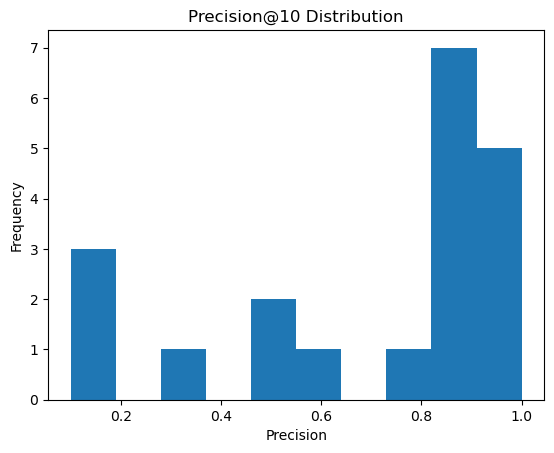

In [63]:
import matplotlib.pyplot as plt

plt.hist(scores)
plt.title("Precision@10 Distribution")
plt.xlabel("Precision")
plt.ylabel("Frequency")
plt.show()

In [1]:
import numpy as np
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

def evaluate_performance(true_labels, retrieved_labels):
    # Calculate Metrics
    # 'macro' calculates metrics for each label and finds their unweighted mean.
    precision = precision_score(true_labels, retrieved_labels, average='macro', zero_division=0)
    recall = recall_score(true_labels, retrieved_labels, average='macro', zero_division=0)
    f1 = f1_score(true_labels, retrieved_labels, average='macro', zero_division=0)
    
    print("--- Performance Analysis ---")
    print(f"Precision: {precision:.4f}")
    print(f"Recall:    {recall:.4f}")
    print(f"F1-Score:  {f1:.4f}")
    
    # Generate Confusion Matrix to see which classes are being confused
    cm = confusion_matrix(true_labels, retrieved_labels)
    plt.figure(figsize=(10, 7))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title('Confusion Matrix of Retrieved Images')
    plt.xlabel('Predicted Class')
    plt.ylabel('True Class')
    plt.show()